In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import zipfile
import shutil

# Origen: zip en Drive
zip_path = '/content/drive/MyDrive/plantvillage_proyecto/data/plantvillage-dataset.zip'

# Destino: almacenamiento LOCAL de Colab (rápido, NO se guarda al apagar)
local_extract = '/content/dataset'

# Verificar si ya está
if os.path.exists(os.path.join(local_extract, 'plantvillage dataset')):
    print("✅ Dataset ya está descomprimido localmente")
else:
    print("⏳ Descomprimiendo a almacenamiento local (mucho más rápido)...")
    os.makedirs(local_extract, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract)
    print("✅ Dataset descomprimido localmente")

# Listar contenido
print("\nContenido:")
for item in os.listdir(local_extract):
    print(f"  - {item}")

⏳ Descomprimiendo a almacenamiento local (mucho más rápido)...
✅ Dataset descomprimido localmente

Contenido:
  - plantvillage dataset


In [3]:
import os

# IMPORTANTE: Ahora usamos la ruta LOCAL, no Drive
base_path = '/content/dataset/plantvillage dataset'

print("Versiones disponibles:")
for v in os.listdir(base_path):
    print(f"  - {v}")

color_path = os.path.join(base_path, 'color')
classes = sorted(os.listdir(color_path))
print(f"\n✅ Total de clases: {len(classes)}")
print(f"\nPrimeras 10 clases:")
for c in classes[:10]:
    print(f"  - {c}")

Versiones disponibles:
  - segmented
  - color
  - grayscale

✅ Total de clases: 38

Primeras 10 clases:
  - Apple___Apple_scab
  - Apple___Black_rot
  - Apple___Cedar_apple_rust
  - Apple___healthy
  - Blueberry___healthy
  - Cherry_(including_sour)___Powdery_mildew
  - Cherry_(including_sour)___healthy
  - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  - Corn_(maize)___Common_rust_
  - Corn_(maize)___Northern_Leaf_Blight


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Configuración visual de las gráficas (estilo profesional)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Crear DataFrame con info de cada imagen
data = []
for class_name in tqdm(classes, desc="Escaneando clases"):
    class_dir = os.path.join(color_path, class_name)
    images = os.listdir(class_dir)

    # Separar planta y enfermedad del nombre de la clase
    parts = class_name.split('___')
    plant = parts[0].replace('_', ' ')
    disease = parts[1].replace('_', ' ') if len(parts) > 1 else 'healthy'

    for img_name in images:
        data.append({
            'class': class_name,
            'plant': plant,
            'disease': disease,
            'is_healthy': 'healthy' in disease.lower(),
            'image_path': os.path.join(class_dir, img_name)
        })

df = pd.DataFrame(data)
print(f"\n✅ Total de imágenes: {len(df):,}")
print(f"✅ Total de plantas distintas: {df['plant'].nunique()}")
print(f"✅ Total de clases (planta+enfermedad): {df['class'].nunique()}")
print(f"✅ Imágenes sanas: {df['is_healthy'].sum():,} ({df['is_healthy'].mean()*100:.1f}%)")
print(f"✅ Imágenes enfermas: {(~df['is_healthy']).sum():,} ({(~df['is_healthy']).mean()*100:.1f}%)")

Escaneando clases: 100%|██████████| 38/38 [00:00<00:00, 384.75it/s]


✅ Total de imágenes: 54,305
✅ Total de plantas distintas: 14
✅ Total de clases (planta+enfermedad): 38
✅ Imágenes sanas: 15,084 (27.8%)
✅ Imágenes enfermas: 39,221 (72.2%)


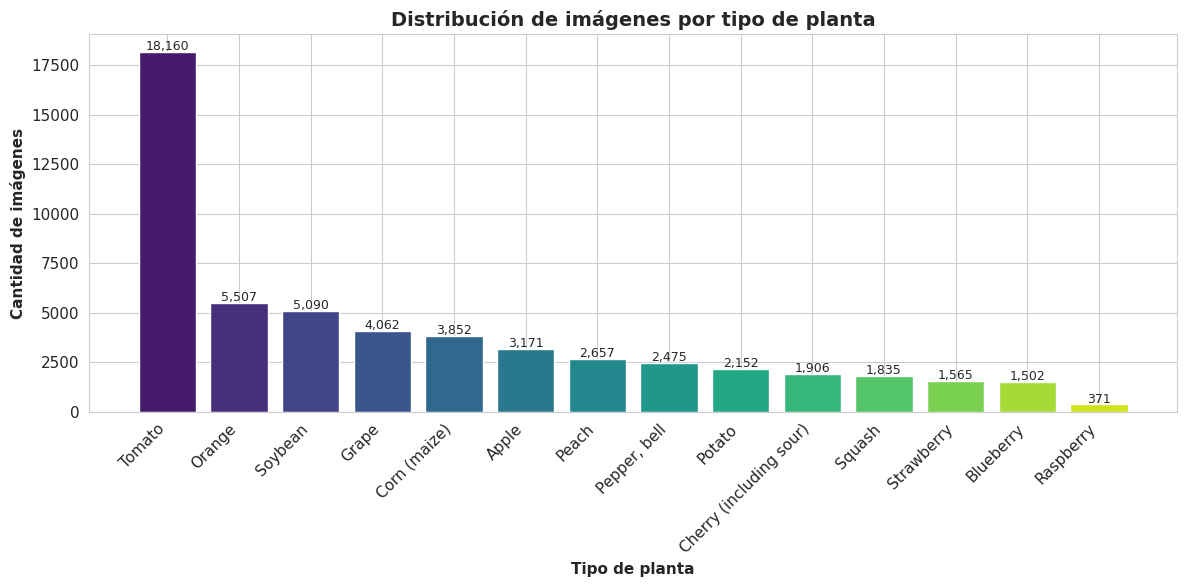

✅ Gráfica guardada en /content/drive/MyDrive/plantvillage_proyecto/figuras/01_dist_plantas.png


In [5]:
# Crear carpeta para guardar las gráficas
os.makedirs('/content/drive/MyDrive/plantvillage_proyecto/figuras', exist_ok=True)
fig_path = '/content/drive/MyDrive/plantvillage_proyecto/figuras'

# Gráfica
plt.figure(figsize=(12, 6))
plant_counts = df['plant'].value_counts()
colors = sns.color_palette("viridis", len(plant_counts))
bars = plt.bar(range(len(plant_counts)), plant_counts.values, color=colors)
plt.xticks(range(len(plant_counts)), plant_counts.index, rotation=45, ha='right')
plt.ylabel('Cantidad de imágenes', fontweight='bold')
plt.xlabel('Tipo de planta', fontweight='bold')
plt.title('Distribución de imágenes por tipo de planta', fontweight='bold', fontsize=14)

# Agregar valores arriba de cada barra
for bar, val in zip(bars, plant_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{fig_path}/01_dist_plantas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada en {fig_path}/01_dist_plantas.png")

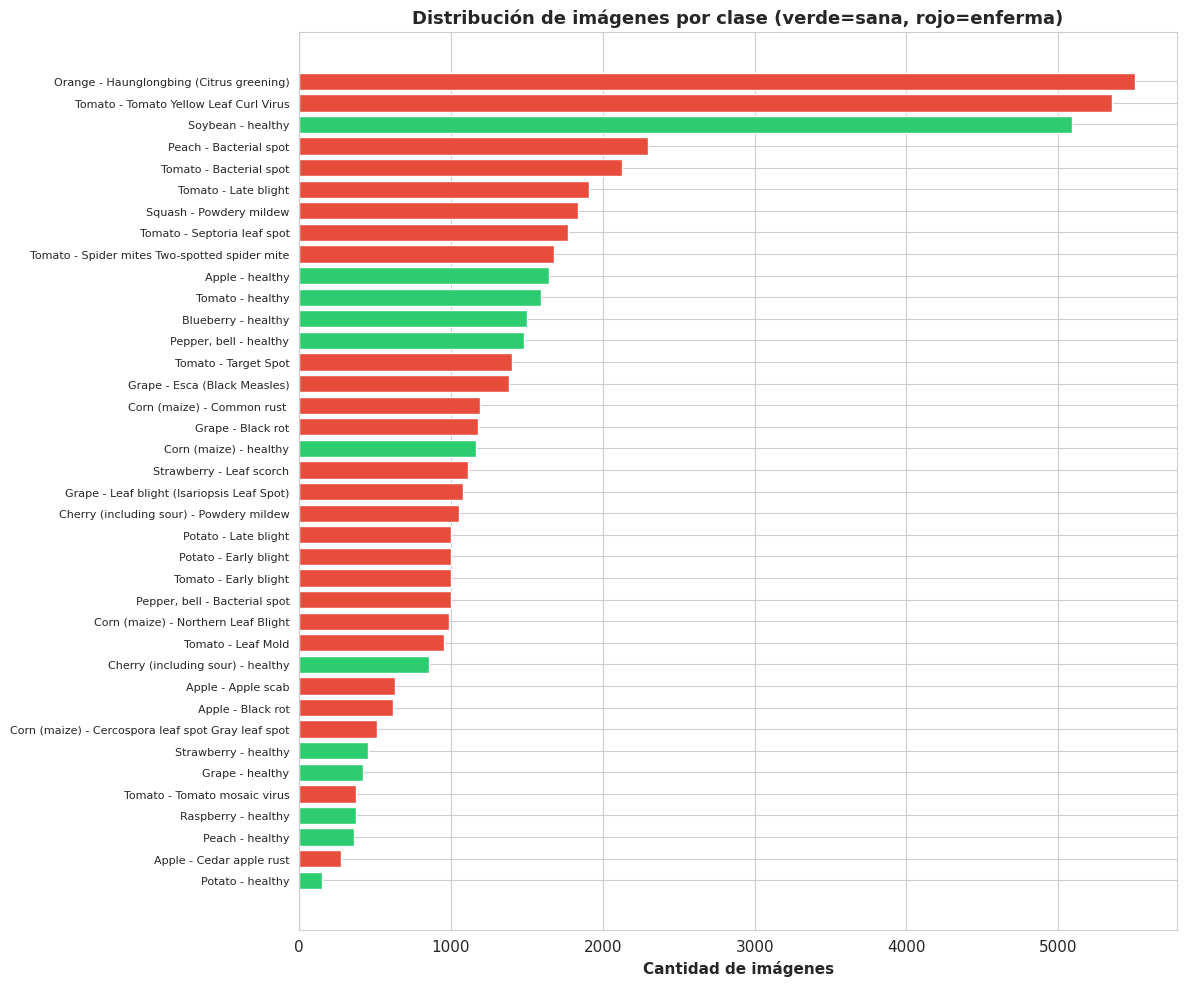

✅ Gráfica guardada

📊 Balance del dataset:
   Clase con más imágenes: Orange___Haunglongbing_(Citrus_greening) (5,507)
   Clase con menos imágenes: Potato___healthy (152)
   Ratio desbalance: 36.23x


In [6]:
plt.figure(figsize=(12, 10))
class_counts = df['class'].value_counts().sort_values()
colors = ['#2ecc71' if 'healthy' in c else '#e74c3c' for c in class_counts.index]
plt.barh(range(len(class_counts)), class_counts.values, color=colors)
plt.yticks(range(len(class_counts)), [c.replace('___', ' - ').replace('_', ' ') for c in class_counts.index], fontsize=8)
plt.xlabel('Cantidad de imágenes', fontweight='bold')
plt.title('Distribución de imágenes por clase (verde=sana, rojo=enferma)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{fig_path}/02_dist_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

# Estadísticas de balance
print(f"\n📊 Balance del dataset:")
print(f"   Clase con más imágenes: {class_counts.idxmax()} ({class_counts.max():,})")
print(f"   Clase con menos imágenes: {class_counts.idxmin()} ({class_counts.min():,})")
print(f"   Ratio desbalance: {class_counts.max()/class_counts.min():.2f}x")

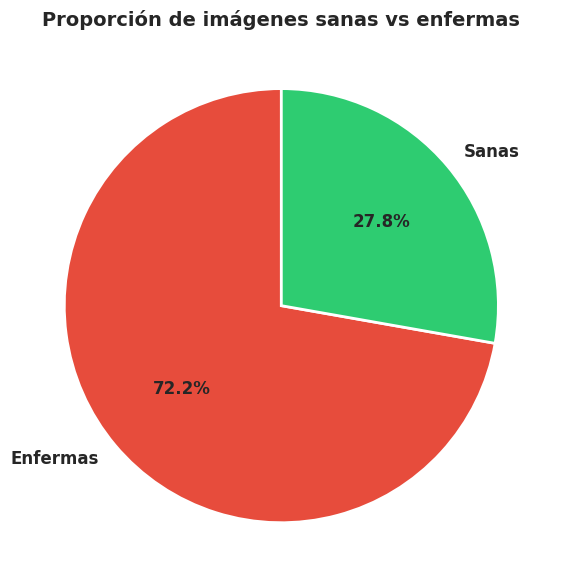

✅ Gráfica guardada


In [7]:
plt.figure(figsize=(8, 6))
health_counts = df['is_healthy'].value_counts()
labels = ['Enfermas', 'Sanas']
colors_pie = ['#e74c3c', '#2ecc71']
plt.pie(health_counts.values, labels=labels, colors=colors_pie,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Proporción de imágenes sanas vs enfermas', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{fig_path}/03_sanas_vs_enfermas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

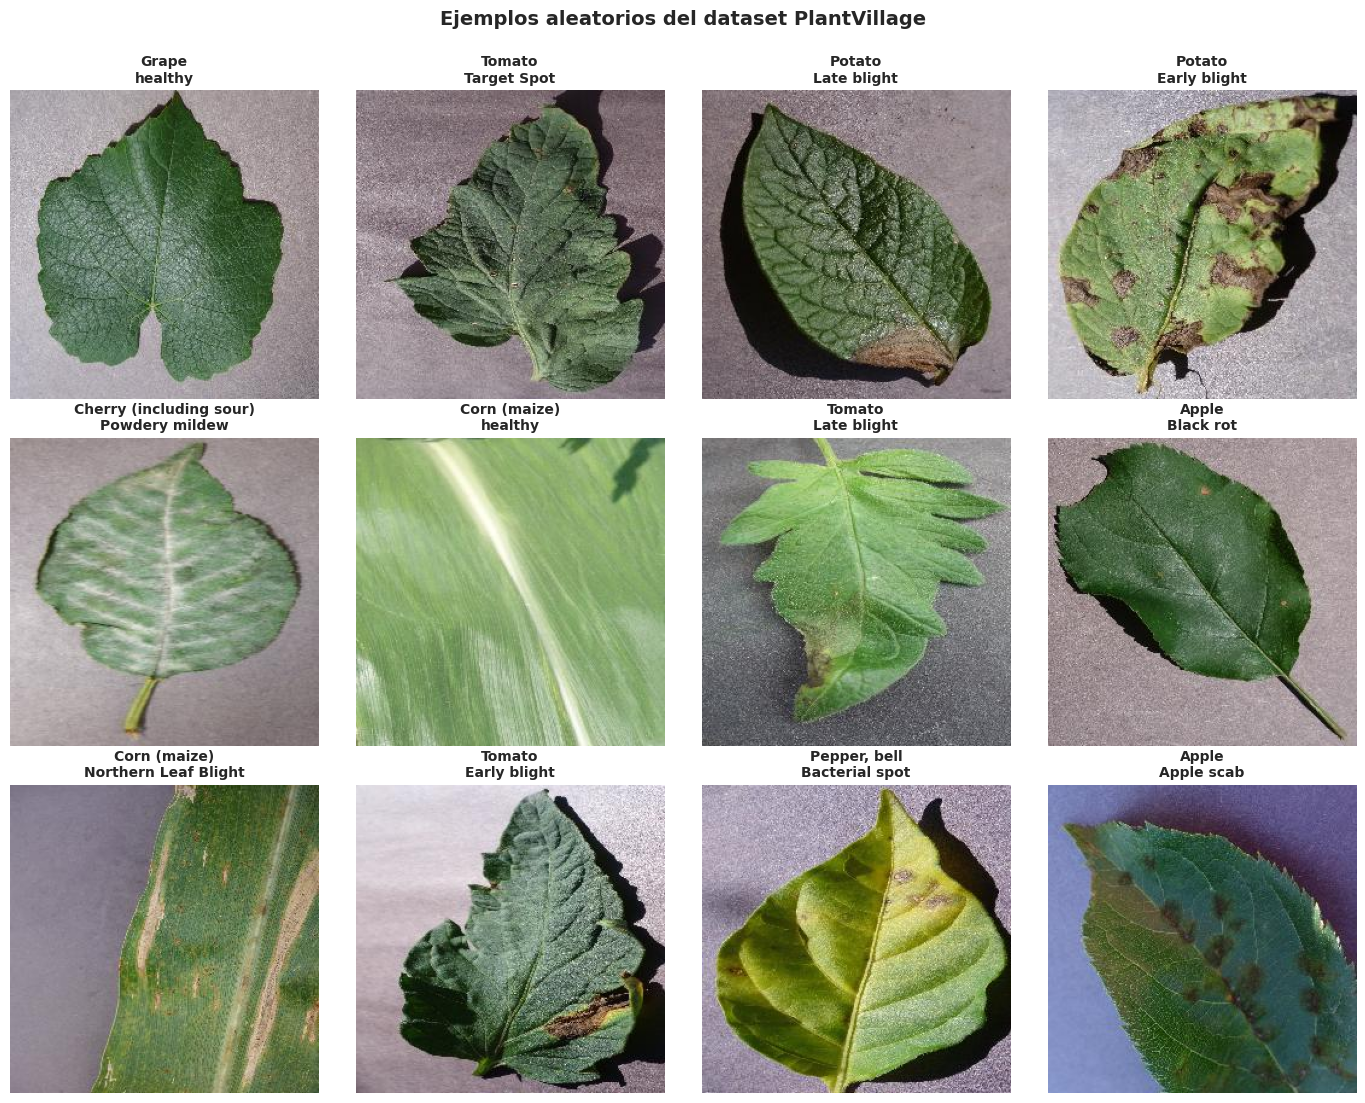

✅ Gráfica guardada


In [8]:
# Muestra una imagen aleatoria de cada una de las primeras 12 clases
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()

sample_classes = np.random.choice(classes, 12, replace=False)

for i, class_name in enumerate(sample_classes):
    class_dir = os.path.join(color_path, class_name)
    img_files = os.listdir(class_dir)
    img_path = os.path.join(class_dir, np.random.choice(img_files))

    img = Image.open(img_path)
    axes[i].imshow(img)
    title = class_name.replace('___', '\n').replace('_', ' ')
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Ejemplos aleatorios del dataset PlantVillage', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{fig_path}/04_ejemplos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")

Analizando dimensiones: 100%|██████████| 500/500 [00:00<00:00, 1022.06it/s]


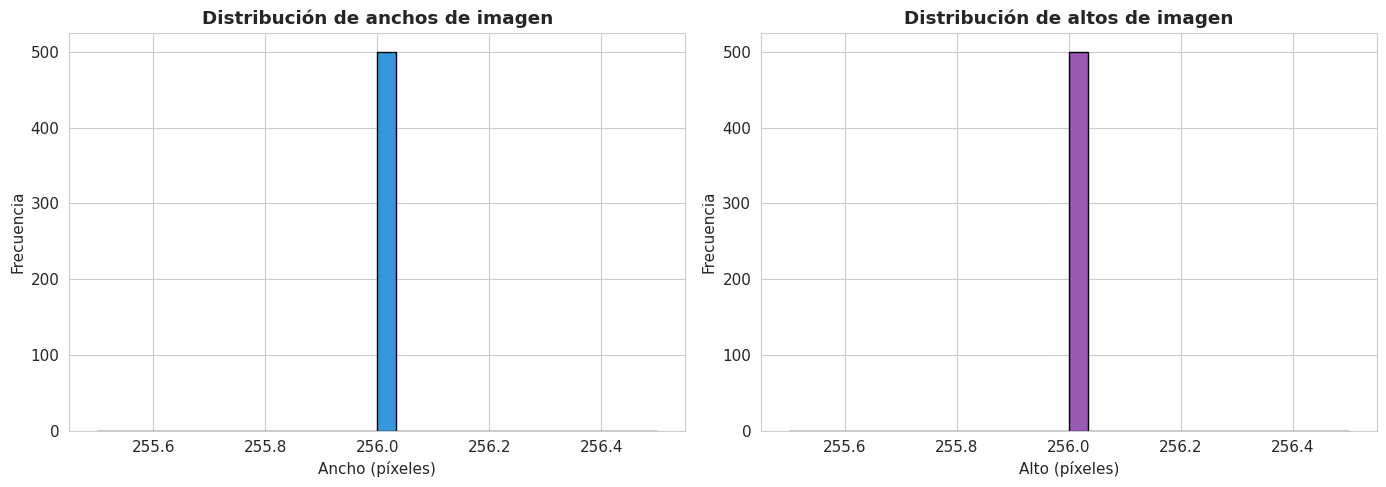


📐 Estadísticas de dimensiones (muestra de 500):
   Ancho:  min=256, max=256, media=256
   Alto:   min=256, max=256, media=256
   Tamaño más común: (256, 256)


In [9]:
# Tomar muestra de 500 imágenes aleatorias para analizar dimensiones
sample = df.sample(500, random_state=42)
widths, heights = [], []

for path in tqdm(sample['image_path'].values, desc="Analizando dimensiones"):
    img = Image.open(path)
    widths.append(img.size[0])
    heights.append(img.size[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Distribución de anchos de imagen', fontweight='bold')
axes[0].set_xlabel('Ancho (píxeles)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(heights, bins=30, color='#9b59b6', edgecolor='black')
axes[1].set_title('Distribución de altos de imagen', fontweight='bold')
axes[1].set_xlabel('Alto (píxeles)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(f'{fig_path}/05_dimensiones.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📐 Estadísticas de dimensiones (muestra de 500):")
print(f"   Ancho:  min={min(widths)}, max={max(widths)}, media={np.mean(widths):.0f}")
print(f"   Alto:   min={min(heights)}, max={max(heights)}, media={np.mean(heights):.0f}")
print(f"   Tamaño más común: {max(set(zip(widths,heights)), key=list(zip(widths,heights)).count)}")

In [10]:
# Resumen completo que vas a citar en el documento técnico
resumen = f"""
═══════════════════════════════════════════════════════
  RESUMEN ESTADÍSTICO DEL DATASET PLANTVILLAGE
═══════════════════════════════════════════════════════

📊 GENERAL:
   • Total de imágenes: {len(df):,}
   • Total de clases (planta+enfermedad): {df['class'].nunique()}
   • Total de tipos de plantas: {df['plant'].nunique()}
   • Plantas: {', '.join(sorted(df['plant'].unique()))}

🌱 BALANCE SANAS/ENFERMAS:
   • Imágenes sanas: {df['is_healthy'].sum():,} ({df['is_healthy'].mean()*100:.1f}%)
   • Imágenes enfermas: {(~df['is_healthy']).sum():,} ({(~df['is_healthy']).mean()*100:.1f}%)

📈 BALANCE DE CLASES:
   • Clase mayoritaria: {class_counts.idxmax()} ({class_counts.max():,} imgs)
   • Clase minoritaria: {class_counts.idxmin()} ({class_counts.min():,} imgs)
   • Ratio de desbalance: {class_counts.max()/class_counts.min():.2f}x
   • Promedio por clase: {class_counts.mean():.0f}
   • Mediana por clase: {class_counts.median():.0f}

📐 DIMENSIONES:
   • Resolución estándar: 256x256 píxeles (mayoría)
   • Formato: RGB (3 canales)

═══════════════════════════════════════════════════════
"""
print(resumen)

# Guardar a archivo
with open('/content/drive/MyDrive/plantvillage_proyecto/figuras/resumen_dataset.txt', 'w') as f:
    f.write(resumen)
print("✅ Resumen guardado en figuras/resumen_dataset.txt")


═══════════════════════════════════════════════════════
  RESUMEN ESTADÍSTICO DEL DATASET PLANTVILLAGE
═══════════════════════════════════════════════════════

📊 GENERAL:
   • Total de imágenes: 54,305
   • Total de clases (planta+enfermedad): 38
   • Total de tipos de plantas: 14
   • Plantas: Apple, Blueberry, Cherry (including sour), Corn (maize), Grape, Orange, Peach, Pepper, bell, Potato, Raspberry, Soybean, Squash, Strawberry, Tomato

🌱 BALANCE SANAS/ENFERMAS:
   • Imágenes sanas: 15,084 (27.8%)
   • Imágenes enfermas: 39,221 (72.2%)

📈 BALANCE DE CLASES:
   • Clase mayoritaria: Orange___Haunglongbing_(Citrus_greening) (5,507 imgs)
   • Clase minoritaria: Potato___healthy (152 imgs)
   • Ratio de desbalance: 36.23x
   • Promedio por clase: 1429
   • Mediana por clase: 1092

📐 DIMENSIONES:
   • Resolución estándar: 256x256 píxeles (mayoría)
   • Formato: RGB (3 canales)

═══════════════════════════════════════════════════════

✅ Resumen guardado en figuras/resumen_dataset.txt


In [11]:
from sklearn.model_selection import train_test_split

# Split estratificado: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['class'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['class'], random_state=42)

print(f"✅ Train: {len(train_df):,} imágenes ({len(train_df)/len(df)*100:.1f}%)")
print(f"✅ Val:   {len(val_df):,} imágenes ({len(val_df)/len(df)*100:.1f}%)")
print(f"✅ Test:  {len(test_df):,} imágenes ({len(test_df)/len(df)*100:.1f}%)")

# Guardar los splits para usarlos en siguientes sprints
splits_path = '/content/drive/MyDrive/plantvillage_proyecto/data/'
train_df.to_csv(f'{splits_path}/train_split.csv', index=False)
val_df.to_csv(f'{splits_path}/val_split.csv', index=False)
test_df.to_csv(f'{splits_path}/test_split.csv', index=False)
print(f"\n✅ Splits guardados en {splits_path}")

✅ Train: 38,013 imágenes (70.0%)
✅ Val:   8,146 imágenes (15.0%)
✅ Test:  8,146 imágenes (15.0%)

✅ Splits guardados en /content/drive/MyDrive/plantvillage_proyecto/data/
